# Practice Lab: Regularization with Ridge, Lasso, and ElasticNet

We are tackling a common problem in Data Science: **Multicollinearity** (when your features are highly correlated with each other) and **Overfitting**. 

To solve this, we will use **Regularization**, which penalizes complex models. You will build and compare four models:
1. Standard Linear Regression (Base Model)
2. Ridge Regression ($L_2$ Penalty)
3. Lasso Regression ($L_1$ Penalty)
4. ElasticNet (Combination of $L_1$ and $L_2$)

### Abalone & The Business Problem
We will use the famous Abalone dataset to predict the age of an abalone (a highly valued marine snail) based on its physical measurements. 

**Why does predicting their age matter?**

Abalones are a premium seafood delicacy, making them vulnerable to overfishing. Strict regulations are in place to ensure abalones are only harvested after they reach a certain age, allowing them time to reproduce. Furthermore, aquaculture farms need to track age to optimize feeding and harvest times for profit. 

Currently, determining an abalone's age is a destructive, expensive, and tedious process: it requires cutting the shell, staining it, and counting the rings under a microscope. **Our goal is to build a Machine Learning model that can predict the age (number of rings) using simple, non-destructive measurements like weight and length.** If successful, we can save fisheries time and money!

**Data Dictionary:**
|Column| Definition |
|------|------------|
|`Sex`|: M (Male), F (Female), I (Infant)|
|`Length`|: Longest shell measurement (mm)|
|`Diameter`|: Perpendicular to length (mm)|
|`Height`|: With meat in shell (mm)|
|`Whole_weight`|: Whole abalone (grams)|
|`Shucked_weight`|: Weight of meat (grams)|
|`Viscera_weight`|: Gut weight after bleeding (grams)|
|`Shell_weight`|: After being dried (grams)|
|`Class` (Target)|: Number of rings. *Note: Age is roughly rings + 1.5 years.*|

In [33]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Load the Data
We will fetch the Abalone dataset directly from OpenML.

In [34]:
# Fetch Abalone dataset (version 1)
abalone = fetch_openml(name="abalone", version=1, as_frame=True, parser='auto')
df = abalone.frame

# Rename the target column from 'Class' to 'Rings' for clarity
df = df.rename(columns={'Class_number_of_rings': 'Rings'})

# Display the first 5 rows
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 2. Exploratory Data Analysis (EDA)
Before modeling, let's understand our data. Regularization is especially useful when features are highly correlated. Let's prove that this dataset has high multicollinearity.

In [3]:
# TODO: Check for missing values in the dataframe
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

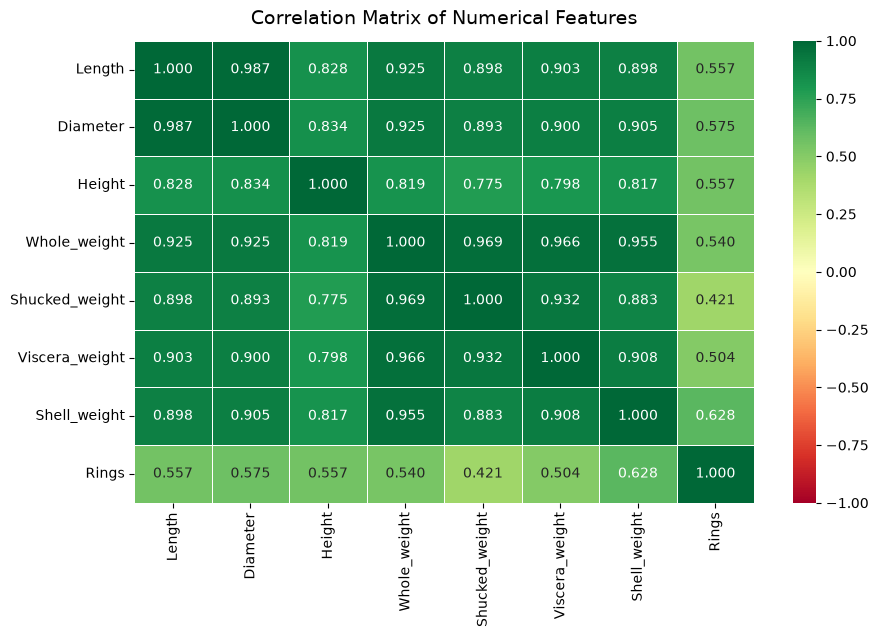

In [38]:
# TODO: Create a correlation matrix for the NUMERICAL features only.
# and NOTE down your observation!
# Hint: Drop the 'Sex' column temporarily or select only numeric columns.
# Optional but recommended: Plot this using sns.heatmap()

X = df.drop(columns=['Sex'])

corr_matrix = X.corr()

plt.subplots(figsize=(10, 6))
plt.title("Correlation Matrix of Numerical Features", fontsize=14, pad=12)
sns.heatmap( corr_matrix , annot=True, fmt=".3f", cmap='RdYlGn', linewidth=.5, vmin=-1, vmax=1)
plt.show()

## 3. Data Preprocessing
Machine Learning models need numbers, not text. We need to handle the categorical `Sex` column and split our data. 

**Crucial Note for Regularization:** You MUST scale your features when using Ridge, Lasso, or ElasticNet. Because regularization penalizes the size of the coefficients, features on larger scales (like thousands) will be penalized unfairly compared to features on smaller scales (like decimals) if they aren't standardized first.

In [39]:
df_encoded = pd.get_dummies(df, columns=['Sex'], drop_first=True, dtype=int)
df_encoded

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15,0,1
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7,0,1
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9,0,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10,0,1
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7,1,0
...,...,...,...,...,...,...,...,...,...,...
4172,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11,0,0
4173,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10,0,1
4174,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9,0,1
4175,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10,0,0


In [50]:
X = df_encoded.drop(columns=['Rings'])
y = df_encoded['Rings']


In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)


In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Don't Repeat Yourself (DRY): Evaluation Function
As good programmers, we want to avoid writing the same evaluation code four times. 

Write a function that takes in a fitted model, the training data, and the testing data, and prints out the $R^2$ and Root Mean Squared Error (RMSE) for BOTH the training and test sets. Comparing train vs. test metrics helps us spot overfitting!

*__Note__: You can add this to your go-to function toolbox!*

In [58]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    print(f"--- {model_name} ---")
    print(f"Train R2: {train_r2}  |  Train RMSE: {train_rmse}")
    print(f"Test R2:  {test_r2}  |  Test RMSE:  {test_rmse}")


## 5. Base Model: Standard Linear Regression
Let's see how a standard linear regression model handles this highly correlated data.

In [44]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression")


Train R2: 0.5349186484312887  Train RMSE: 2.2113127461238995
Test R2: 0.5497455295384085  Test RMSE: 2.1115883928019126


## 6. Regularization Models
Now, let's apply penalties to our model to handle the multicollinearity.

Instead of guessing the penalty term (`alpha`), we will use Scikit-Learn's built-in Cross-Validation models (`RidgeCV`, `LassoCV`, `ElasticNetCV`). These models automatically try a list of different alphas and select the one that performs best!

### RIDGE REGRESSION (L2 Penalty)

In [62]:
alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_model = RidgeCV(alphas=alphas_to_test, cv=5)
ridge_model.fit(X_train_scaled, y_train)
evaluate_model(ridge_model, X_train_scaled, X_test_scaled, y_train, y_test, "Ridge Regression")
print(ridge_model.alpha_)


--- Ridge Regression ---
Train R2: 0.5348868528219921  |  Train RMSE: 2.211388333797124
Test R2:  0.549668525592272  |  Test RMSE:  2.1117689503510366
1.0


### LASSO REGRESSION (L1 Penalty)

__Note__: You can provide a custom list to `LassoCV` and `ElasticNetCV` if you want to, but it is generally best practice to leave it blank and let Scikit-Learn automatically calculate the optimal path for you.

In [63]:
lasso_model = LassoCV(cv=5, random_state=10)
lasso_model.fit(X_train_scaled, y_train)
evaluate_model(lasso_model, X_train_scaled, X_test_scaled, y_train, y_test, "Lasso Regression")
print(lasso_model.alpha_)


--- Lasso Regression ---
Train R2: 0.5347195860155985  |  Train RMSE: 2.2117859344850697
Test R2:  0.5493070327587068  |  Test RMSE:  2.1126163663638957
0.003102557702171799


### ELASTICNET REGRESSION (L1 + L2 Penalty)

In [64]:
elasticnet_model = ElasticNetCV(cv=5, random_state=10)
elasticnet_model.fit(X_train_scaled, y_train)
evaluate_model(elasticnet_model, X_train_scaled, X_test_scaled, y_train, y_test, "ElasticNet Regression")
print(elasticnet_model.alpha_)


--- ElasticNet Regression ---
Train R2: 0.5334525664467988  |  Train RMSE: 2.2147953786403107
Test R2:  0.5480131747768138  |  Test RMSE:  2.115646662779854
0.004082551587352136


## 7. Feature Selection with Lasso
One of the superpower traits of Lasso ($L_1$ regularization) is that it can shrink the coefficients of useless or highly correlated features down to **exactly zero**. This acts as automatic feature selection.

Let's look at the coefficients of our models to see this in action.

In [65]:
# Provided Code: Run this cell to compare coefficients!
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Linear_Coef': lr_model.coef_,       # Update 'lr_model' if you named your Linear Regression variable differently
    'Ridge_Coef': ridge_model.coef_,     # Update 'ridge_model' if needed
    'Lasso_Coef': lasso_model.coef_,      # Update 'lasso_model' if needed
    'ElasticNet_Coef': elasticnet_model.coef_
})

# Display the coefficients
coef_df.round(3)

,Feature,Linear_Coef,Ridge_Coef,Lasso_Coef,ElasticNet_Coef
0,Length,0.020,0.025,0.000,0.029
1,Diameter,0.984,0.976,0.981,0.942
2,Height,0.440,0.441,0.437,0.442
3,Whole_weight,4.385,4.202,3.955,3.161
4,Shucked_weight,-4.370,-4.283,-4.168,-3.776
5,Viscera_weight,-1.125,-1.083,-0.987,-0.817
6,Shell_weight,1.254,1.315,1.382,1.640
7,Sex_I,-0.388,-0.390,-0.389,-0.396
8,Sex_M,0.012,0.012,0.008,0.006


__Q1. Which feature(s) did Lasso completely drop (set to 0)?__ 

__Answer:__ Lasso dropped the Length feature (coefficient shrunk to 0.000). This makes sense since Length is very highly correlated with Diameter, so Lasso decided Diameter alone was enough and removed the redundant one.

__Q2. How does ElasticNet compare to Lasso and Ridge here?__

__Answer:__ ElasticNet sits in between the two. Like Ridge, it shrinks all the coefficients smoothly instead of forcing them to zero, but the shrinkage is stronger than Ridge because it also has the L1 part like Lasso. In this case it didn't drop any feature completely to 0, it just pulled the big coefficients (like Whole_weight and Shucked_weight) down more than Ridge did.


## 8. Communicating Results to Stakeholders

**Scenario:** 
Imagine you are presenting these findings to the manager of a seafood fishery. They have no background in data science or math. They want to know if they can trust this model to replace the manual, time-consuming process of cutting abalone shells and counting rings under a microscope. 

**How to phrase your answer:**
When speaking to stakeholders, avoid throwing raw math at them. Translate the metrics into real-world impact. 

*Example using a Real Estate Model:*
*   ❌ **Bad:** "The model has an RMSE of 25000 and an $R^2$ of 0.85."
*   ✅ **Good:** "Our model is highly accurate, capturing about 85% of the factors that drive house prices. When it makes a prediction, it is typically off by about $25,000 on average."

**Your Task:**
Double-click this text cell. Based on your best model's RMSE and $R^2$ scores, write a 3-4 sentence explanation answering the fishery manager's question. Be honest about whether the model is accurate enough to replace humans entirely, or if it should just be used as an estimation tool.

Our best model (ElasticNet) explains around 55% of what causes the differences in an abalone's age, and on average its predictions are off by roughly 2 rings. That means it won't give you the exact ring count every time, but it gets close enough to be useful for quick, non-destructive estimates. I would not recommend fully replacing the manual counting process with this model yet, especially for cases where an exact age matters, but it works well as a fast first estimate that can save time and only send borderline cases for manual checking.


# Now it’s your turn!
1. Derive at least one new feature that adds value to the dataset.
2. Apply a feature selection technique to eliminate uninformative variables.
3. Document your reasoning in clean Markdown cells as you go!

In [49]:
df_fe = df_encoded.copy()
df_fe['Volume'] = df_fe['Length'] * df_fe['Diameter'] * df_fe['Height']

X_fe = df_fe.drop(columns=['Rings'])
y_fe = df_fe['Rings']

X_fe_train, X_fe_test, y_fe_train, y_fe_test = train_test_split(X_fe, y_fe, test_size=0.2, random_state=10)

scaler_fe = StandardScaler()
X_fe_train_scaled = scaler_fe.fit_transform(X_fe_train)
X_fe_test_scaled = scaler_fe.transform(X_fe_test)

lasso_fe = LassoCV(cv=5, random_state=10)
lasso_fe.fit(X_fe_train_scaled, y_fe_train)
evaluate_model(lasso_fe, X_fe_train_scaled, X_fe_test_scaled, y_fe_train, y_fe_test, "Lasso with Volume feature")

fe_coef = pd.DataFrame({'Feature': X_fe.columns, 'Coef': lasso_fe.coef_})
fe_coef.round(3)


Train R2: 0.5435757742143619  Train RMSE: 2.1906351407168794
Test R2: 0.5615382521495429  Test RMSE: 2.0837523599070944


,Feature,Coef
0,Length,0.000
1,Diameter,1.055
2,Height,0.954
3,Whole_weight,4.093
4,Shucked_weight,-3.883
5,Viscera_weight,-0.739
6,Shell_weight,1.704
7,Sex_I,-0.348
8,Sex_M,0.000
9,Volume,-1.487
